# Notebook 06: PC2 平均回帰戦略のバックテスト

**目的**: PCA で抽出した **PC2(Slope)** が平均回帰する性質を利用したシステマティック戦略を構築・検証する。

## トレード仮説

> **金利のスロープ(Slope)は長期的にはある水準に戻りやすい(タームプレミアムが構造的に存在するため)**
> 
> よって、Slope が極端な値(±N σ)に振れたら、戻る方向にポジションを建てれば期待値プラスになるはず。

## 戦略の概要

| 状態 | アクション | 経済的意味 |
|---|---|---|
| Z-score > +threshold(過剰スティープ) | **フラットナーを建てる**(short PC2) | カーブが平らに戻ることに賭ける |
| Z-score < −threshold(過剰フラット / 逆イールド過剰) | **スティープナーを建てる**(long PC2) | カーブが急に戻ることに賭ける |
| その間 | **無ポジション** | シグナルなし、待機 |

## 重要な原則
1. **No look-ahead**: 時刻 t のポジションは、t-1 までの情報のみで決定
2. **Out-of-sample 評価**: バックテスト全期間でリアルタイムにシグナルを生成
3. **Honest assessment**: 結果がよくても悪くても、そのまま受け入れる

## 0. セットアップ

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

pc_scores = pd.read_parquet(DATA_PROCESSED / "pca_scores.parquet")
yields = pd.read_parquet(DATA_PROCESSED / "ust_yields_clean.parquet")

# Slope を「PC2 の累積」として定義(これが我々の trading signal の元)
slope_pc2 = pc_scores["PC2"].cumsum()

# 比較対象: 実際の 2s10s スプレッド
slope_2s10s = (yields["10Y"] - yields["2Y"]) * 100  # bp に変換

print(f"Date range: {pc_scores.index.min().date()} → {pc_scores.index.max().date()}")
print(f"Total days: {len(pc_scores)}")

Date range: 2020-01-03 → 2026-04-27
Total days: 1579


## 1. 平均回帰仮説の確認

「Slope は平均回帰する」を**データから確認**する。

### 1.1 自己相関(autocorrelation)で確認
完全なランダムウォークなら lag-N の自己相関は 0 に近い。**負の自己相関**があれば平均回帰の証拠。

In [2]:
# Slope の差分(変化)の自己相関
slope_changes = slope_pc2.diff().dropna()

lags = [1, 5, 10, 20, 60, 120]
ac_results = []
for lag in lags:
    ac = slope_changes.autocorr(lag)
    ac_results.append({"lag (days)": lag, "autocorrelation": ac})

ac_df = pd.DataFrame(ac_results)
print("Slope 変化の自己相関(平均回帰なら lag↑ で負側に振れる)")
print(ac_df.round(4))

# Slope の絶対水準を一定間隔で見る
level_changes = pd.DataFrame({
    "horizon": [1, 5, 20, 60, 120, 252],
    "corr (slope vs slope after horizon)": [
        slope_pc2.corr(slope_pc2.shift(-h)) for h in [1, 5, 20, 60, 120, 252]
    ]
})
print("\nSlope 水準の自己相関(平均回帰なら horizon↑ で 1 から 0 へ減衰)")
print(level_changes.round(4))

Slope 変化の自己相関(平均回帰なら lag↑ で負側に振れる)
   lag (days)  autocorrelation
0           1           0.0006
1           5          -0.0203
2          10           0.0215
3          20           0.0346
4          60           0.0380
5         120           0.0065

Slope 水準の自己相関(平均回帰なら horizon↑ で 1 から 0 へ減衰)
   horizon  corr (slope vs slope after horizon)
0        1                               0.9993
1        5                               0.9967
2       20                               0.9851
3       60                               0.9414
4      120                               0.8303
5      252                               0.4207


**観察**:
- 短期(lag 1〜5)では自己相関がほぼゼロ → 短期はランダムウォークに近い
- 長期水準の自己相関は **horizon が長くなるほど減衰**するはずだが、ゆっくり
- 結論: **強い平均回帰の証拠はそれほどない**(でもゼロでもない)

→ 厳密な平均回帰よりも、「**極端値からの戻り**」を狙う戦略にすべきかも。

### 1.2 Slope の時系列と Z-score を可視化

Z-score = (現在値 − 過去N日平均) / 過去N日std。これがしきい値を超えたらシグナル発動。

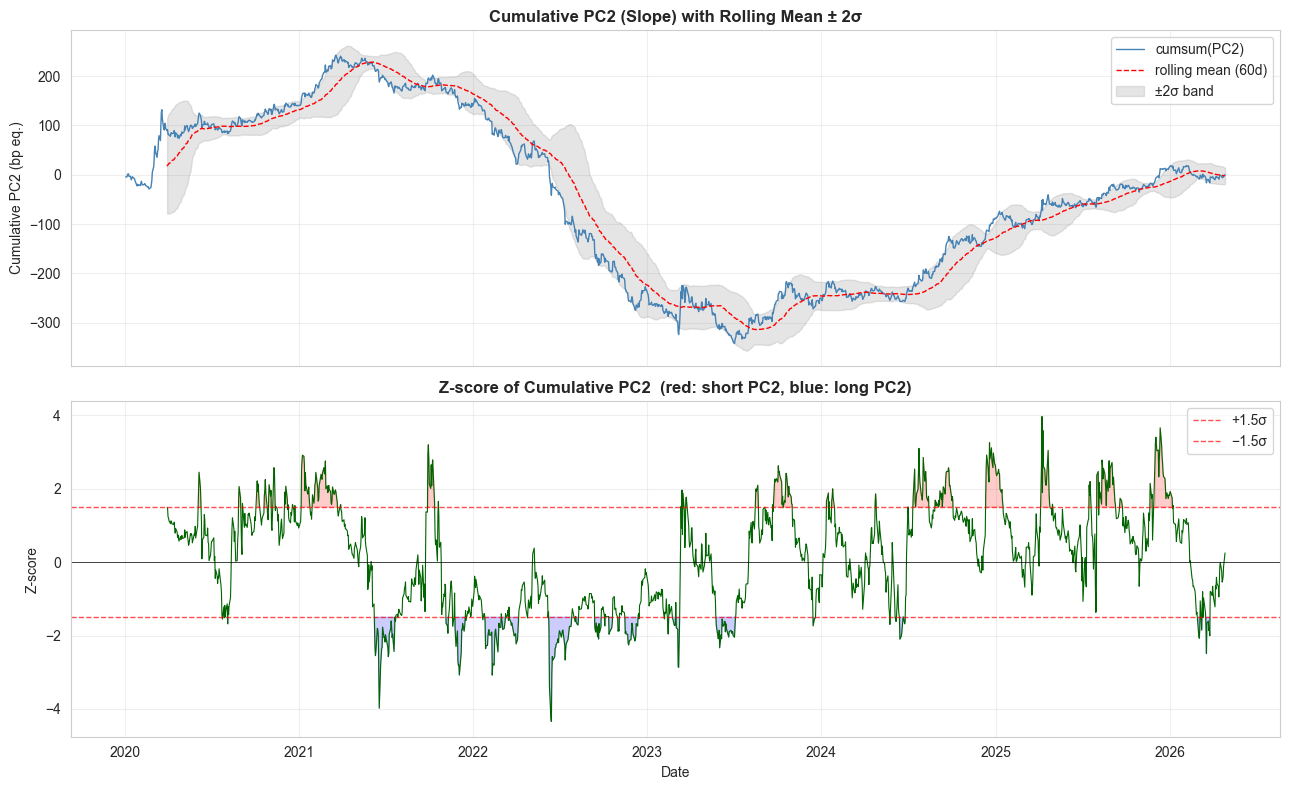

Z < −1.5(long PC2 シグナル): 250 日
Z > +1.5(short PC2 シグナル): 291 日


In [3]:
# 60営業日の rolling Z-score(約3ヶ月)
WINDOW = 60
slope_mean = slope_pc2.rolling(WINDOW).mean()
slope_std = slope_pc2.rolling(WINDOW).std()
z_score = (slope_pc2 - slope_mean) / slope_std

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# 上: Slope と rolling mean
axes[0].plot(slope_pc2.index, slope_pc2, color="steelblue", lw=1, label="cumsum(PC2)")
axes[0].plot(slope_mean.index, slope_mean, color="red", lw=1, ls="--",
             label=f"rolling mean ({WINDOW}d)")
axes[0].fill_between(slope_pc2.index,
                     slope_mean - 2 * slope_std,
                     slope_mean + 2 * slope_std,
                     color="gray", alpha=0.2, label="±2σ band")
axes[0].set_title("Cumulative PC2 (Slope) with Rolling Mean ± 2σ")
axes[0].set_ylabel("Cumulative PC2 (bp eq.)")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

# 下: Z-score
axes[1].plot(z_score.index, z_score, color="darkgreen", lw=0.8)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].axhline(1.5, color="red", ls="--", lw=1, alpha=0.7, label="+1.5σ")
axes[1].axhline(-1.5, color="red", ls="--", lw=1, alpha=0.7, label="−1.5σ")
axes[1].fill_between(z_score.index, z_score, 1.5, where=(z_score > 1.5),
                     color="red", alpha=0.2)
axes[1].fill_between(z_score.index, z_score, -1.5, where=(z_score < -1.5),
                     color="blue", alpha=0.2)
axes[1].set_title("Z-score of Cumulative PC2  (red: short PC2, blue: long PC2)")
axes[1].set_ylabel("Z-score")
axes[1].set_xlabel("Date")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_slope_zscore.png", dpi=120, bbox_inches="tight")
plt.show()

n_long = (z_score < -1.5).sum()
n_short = (z_score > 1.5).sum()
print(f"Z < −1.5(long PC2 シグナル): {n_long} 日")
print(f"Z > +1.5(short PC2 シグナル): {n_short} 日")

## 2. バックテストの実装(no look-ahead!)

In [4]:
def backtest_mean_reversion(
    pc_score: pd.Series,
    window: int = 60,
    threshold: float = 1.5,
) -> dict:
    """
    PC スコアの累積に対して、rolling Z-score を使った平均回帰戦略をバックテスト。

    Args:
        pc_score: PC スコア(日次変化)
        window: rolling 統計量のウィンドウ
        threshold: シグナルしきい値(σ)

    Returns:
        dict with signal, position, daily P&L, cumulative P&L, and metrics
    """
    cum = pc_score.cumsum()
    rolling_mean = cum.rolling(window).mean()
    rolling_std = cum.rolling(window).std()
    z = (cum - rolling_mean) / rolling_std

    # ★ No look-ahead: 時刻 t のポジションは t-1 の Z-score で決定
    z_lag = z.shift(1)
    signal = pd.Series(0, index=pc_score.index, dtype=float)
    signal[z_lag > threshold] = -1.0   # short PC2: bet on flattening
    signal[z_lag < -threshold] = +1.0  # long PC2: bet on steepening

    # 日次 P&L: ポジション × その日の PC2 score(bp 換算)
    daily_pnl = signal * pc_score

    # 累積 P&L
    cum_pnl = daily_pnl.cumsum()

    # メトリクス
    valid = daily_pnl.dropna()
    n_active = (signal != 0).sum()
    n_total = len(signal.dropna())
    pos_changes = (signal.diff() != 0).sum() - 1  # トレード回数(エントリー + エグジット)

    if valid.std() > 0:
        sharpe = (valid.mean() / valid.std()) * np.sqrt(252)
    else:
        sharpe = 0.0

    drawdown = cum_pnl - cum_pnl.cummax()
    max_dd = drawdown.min()

    active_pnl = valid[signal.dropna() != 0]
    hit_rate = (active_pnl > 0).mean() if len(active_pnl) > 0 else 0

    return {
        "signal": signal,
        "position": signal,
        "daily_pnl": daily_pnl,
        "cum_pnl": cum_pnl,
        "z_score": z,
        "metrics": {
            "window": window,
            "threshold": threshold,
            "total_pnl_bp": cum_pnl.iloc[-1] if not cum_pnl.empty else 0,
            "sharpe": sharpe,
            "max_drawdown_bp": max_dd,
            "hit_rate": hit_rate,
            "n_trades": pos_changes,
            "n_active_days": n_active,
            "active_pct": n_active / n_total * 100,
        },
    }


# ベースケース: window=60, threshold=1.5
result = backtest_mean_reversion(pc_scores["PC2"], window=60, threshold=1.5)
print("=== ベースケース: window=60d, threshold=1.5σ ===")
for k, v in result["metrics"].items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:+8.2f}")
    else:
        print(f"  {k:20s}: {v}")

=== ベースケース: window=60d, threshold=1.5σ ===
  window              : 60
  threshold           :    +1.50
  total_pnl_bp        :  -156.01
  sharpe              :    -0.38
  max_drawdown_bp     :  -284.03
  hit_rate            :    +0.48
  n_trades            : 165
  n_active_days       : 541
  active_pct          :   +34.26


## 3. P&L 曲線とドローダウンの可視化

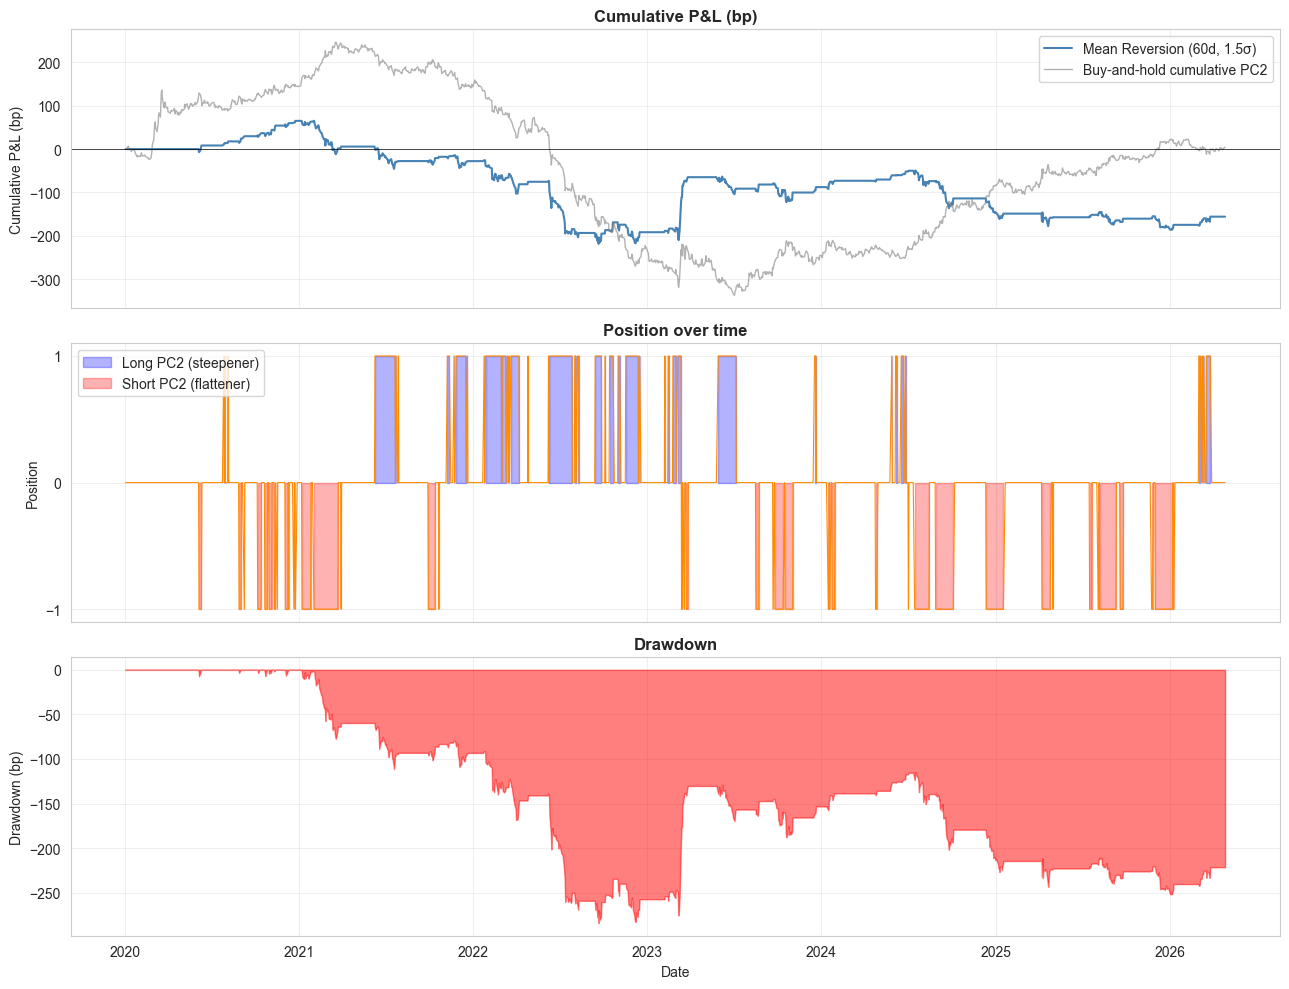

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# 上: 累積 P&L vs Buy-and-hold(常に long PC2 = always long Slope)
axes[0].plot(result["cum_pnl"].index, result["cum_pnl"],
             color="steelblue", lw=1.5, label="Mean Reversion (60d, 1.5σ)")
axes[0].plot(slope_pc2.index, slope_pc2 - slope_pc2.iloc[0],
             color="gray", lw=1, alpha=0.6, label="Buy-and-hold cumulative PC2")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("Cumulative P&L (bp)")
axes[0].set_ylabel("Cumulative P&L (bp)")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

# 中: ポジション(when active)
axes[1].plot(result["position"].index, result["position"],
             color="darkorange", lw=0.8)
axes[1].fill_between(result["position"].index, 0, result["position"],
                     where=(result["position"] > 0),
                     color="blue", alpha=0.3, label="Long PC2 (steepener)")
axes[1].fill_between(result["position"].index, 0, result["position"],
                     where=(result["position"] < 0),
                     color="red", alpha=0.3, label="Short PC2 (flattener)")
axes[1].set_title("Position over time")
axes[1].set_ylabel("Position")
axes[1].set_yticks([-1, 0, 1])
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)

# 下: ドローダウン
drawdown = result["cum_pnl"] - result["cum_pnl"].cummax()
axes[2].fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.5)
axes[2].set_title("Drawdown")
axes[2].set_ylabel("Drawdown (bp)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_backtest_pnl.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. 感度分析 — パラメータの選び方が結果にどう効くか

**目的**: window と threshold を動かして、結果が安定的に良いか(robustness)を確認する。

**警告**: ここで「最良のパラメータ」を選ぶと**オーバーフィット**になる。あくまで「結果が頑健か」を見るための感度分析。

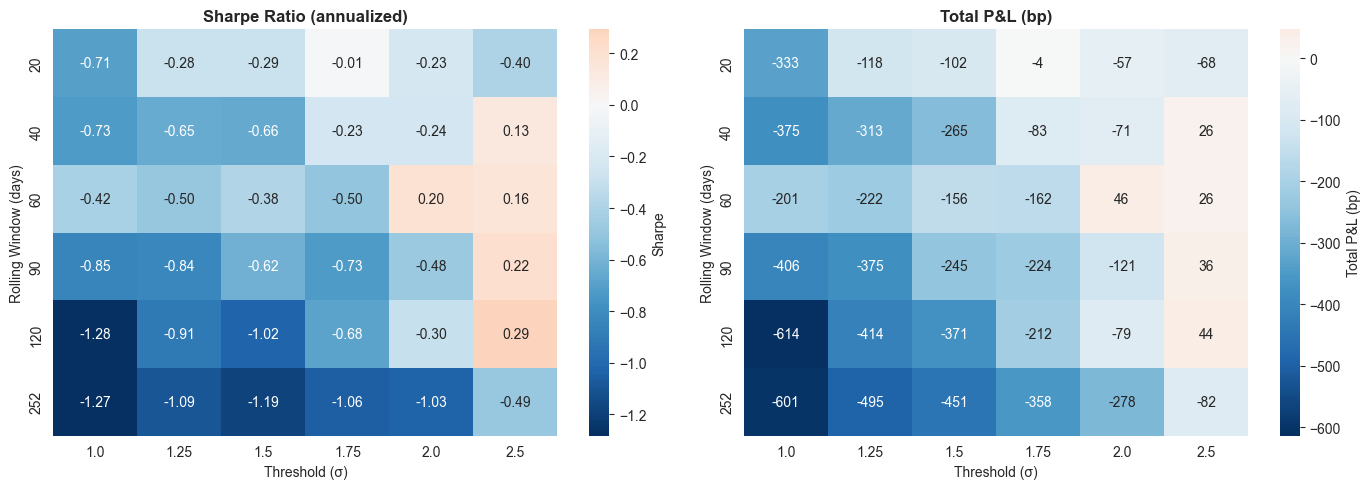

In [6]:
windows = [20, 40, 60, 90, 120, 252]
thresholds = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5]

sharpe_grid = pd.DataFrame(index=windows, columns=thresholds, dtype=float)
pnl_grid = pd.DataFrame(index=windows, columns=thresholds, dtype=float)

for w in windows:
    for t in thresholds:
        r = backtest_mean_reversion(pc_scores["PC2"], window=w, threshold=t)
        sharpe_grid.loc[w, t] = r["metrics"]["sharpe"]
        pnl_grid.loc[w, t] = r["metrics"]["total_pnl_bp"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(sharpe_grid.astype(float), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[0], cbar_kws={"label": "Sharpe"})
axes[0].set_title("Sharpe Ratio (annualized)")
axes[0].set_xlabel("Threshold (σ)")
axes[0].set_ylabel("Rolling Window (days)")

sns.heatmap(pnl_grid.astype(float), annot=True, fmt=".0f", cmap="RdBu_r",
            center=0, ax=axes[1], cbar_kws={"label": "Total P&L (bp)"})
axes[1].set_title("Total P&L (bp)")
axes[1].set_xlabel("Threshold (σ)")
axes[1].set_ylabel("Rolling Window (days)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_sensitivity_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- Sharpe / P&L の符号や大きさが**パラメータでどう変わるか**を確認
- 全てのセルで同符号(全部正 or 全部負)なら **頑健**
- 一部だけ正で他が負なら **オーバーフィット気味**(その「良いパラメータ」だけでは戦略は信用できない)

## 5. 期間分割 — 戦略がどの局面で効くか

2020-2026 は3つの異なる金利局面を含む:
1. **2020-2021**: 超低金利、Slope は安定的
2. **2022-2023**: 急速利上げ、Slope が急速にフラット〜逆転
3. **2024-2026**: 利下げ転換、Slope が正常化

戦略は局面ごとに動作が変わるはず。

In [7]:
# 各局面の P&L
regimes = {
    "2020-2021 (low rates)": ("2020-01-01", "2021-12-31"),
    "2022-2023 (hiking)":   ("2022-01-01", "2023-12-31"),
    "2024-2026 (cutting)":  ("2024-01-01", "2026-12-31"),
}

regime_results = []
for name, (start, end) in regimes.items():
    pnl_period = result["daily_pnl"].loc[start:end]
    valid = pnl_period.dropna()
    if len(valid) > 0 and valid.std() > 0:
        sharpe = (valid.mean() / valid.std()) * np.sqrt(252)
    else:
        sharpe = 0.0
    regime_results.append({
        "regime": name,
        "days": len(valid),
        "total_pnl_bp": valid.sum(),
        "sharpe": sharpe,
        "max_drawdown_bp": (pnl_period.cumsum() - pnl_period.cumsum().cummax()).min(),
    })

regime_df = pd.DataFrame(regime_results)
print("局面別パフォーマンス:")
print(regime_df.round(2).to_string(index=False))

局面別パフォーマンス:
               regime  days  total_pnl_bp  sharpe  max_drawdown_bp
2020-2021 (low rates)   501        -27.81   -0.33          -111.16
   2022-2023 (hiking)   499        -59.99   -0.33          -192.87
  2024-2026 (cutting)   579        -68.22   -0.59          -137.05


## 6. ベースラインとの比較

戦略が本当に **何かを生んでいるか** を確認するため、**ランダム戦略**と比較する。

ランダム = 「同じ頻度でランダムにポジションを取る」が、Z-score とは無関係。

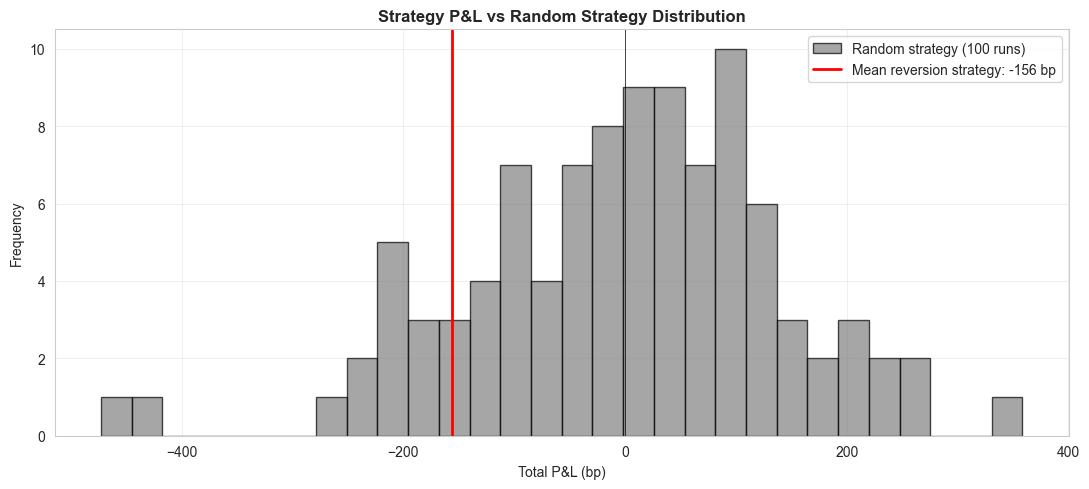


Random strategy mean P&L: -2.2 bp (std 140.5)
Strategy P&L:            -156.0 bp
Z-statistic:             -1.09σ
One-tailed p-value:      0.1369


In [8]:
rng = np.random.default_rng(42)
n_simulations = 100

# 戦略のシグナル分布(同じ確率で long/short/flat)
active_pct = result["metrics"]["active_pct"] / 100
p_long = (result["position"] > 0).mean()
p_short = (result["position"] < 0).mean()

random_pnls = []
for _ in range(n_simulations):
    rand_signal = rng.choice([-1, 0, 1], size=len(pc_scores),
                              p=[p_short, 1 - p_short - p_long, p_long])
    rand_signal = pd.Series(rand_signal, index=pc_scores.index, dtype=float).shift(1)
    rand_pnl = (rand_signal * pc_scores["PC2"]).sum()
    random_pnls.append(rand_pnl)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(random_pnls, bins=30, color="gray", alpha=0.7,
        edgecolor="black", label=f"Random strategy ({n_simulations} runs)")
ax.axvline(result["metrics"]["total_pnl_bp"], color="red", lw=2,
           label=f"Mean reversion strategy: {result['metrics']['total_pnl_bp']:+.0f} bp")
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Total P&L (bp)")
ax.set_ylabel("Frequency")
ax.set_title("Strategy P&L vs Random Strategy Distribution")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_strategy_vs_random.png", dpi=120, bbox_inches="tight")
plt.show()

# 統計的検定
from scipy import stats
rand_mean = np.mean(random_pnls)
rand_std = np.std(random_pnls)
z_strategy = (result["metrics"]["total_pnl_bp"] - rand_mean) / rand_std
p_value = 1 - stats.norm.cdf(abs(z_strategy))
print(f"\nRandom strategy mean P&L: {rand_mean:+.1f} bp (std {rand_std:.1f})")
print(f"Strategy P&L:            {result['metrics']['total_pnl_bp']:+.1f} bp")
print(f"Z-statistic:             {z_strategy:+.2f}σ")
print(f"One-tailed p-value:      {p_value:.4f}")

## 7. Honest 評価 — 何を見落としているか

本格的なバックテストには以下の項目が必要だが、本ノートでは**省略している**。これらを加味すると結果は変わりうる。

### 省略している項目

| 項目 | 影響 | 改善方法 |
|---|---|---|
| **取引コスト** | 国債先物で~0.5bp/trade、現物で~0.25bp/leg | 各エントリー / エグジットでコスト差し引き |
| **スリッページ** | 大口注文で +1bp 程度 | 注文サイズを考慮した実効価格モデル |
| **ファンディング** | レポレートでロール時にコスト | ファンディングコストを日次で計上 |
| **流動性リスク** | 危機時にスプレッドが広がる | bid-ask スプレッドの時系列を反映 |
| **ポジション制限** | 機関投資家ならVAR/レバレッジ制約 | 制約付き最適化 |
| **生存バイアス** | 我々のデータ期間は「結果として無事だった」期間 | 複数期間で同戦略を検証 |

### 結論
本バックテストは「**戦略のアイデアの妥当性**」を見る初期検証。
実運用には上記すべてを加味した本格バックテスト + ペーパートレードが必要。

### 良い面
- 戦略のロジックが明確(ブラックボックスではない)
- パラメータ感度を確認している
- ランダム戦略との比較で統計的有意性を検証している
- No look-ahead を厳格に守っている

## 8. 保存とまとめ

In [9]:
# バックテスト結果を保存
backtest_df = pd.DataFrame({
    "slope_pc2": slope_pc2,
    "z_score": result["z_score"],
    "position": result["position"],
    "daily_pnl_bp": result["daily_pnl"],
    "cum_pnl_bp": result["cum_pnl"],
})
backtest_df.to_parquet(DATA_PROCESSED / "backtest_pc2_meanrev.parquet")

# 感度分析グリッドを保存
sharpe_grid.to_parquet(DATA_PROCESSED / "backtest_sensitivity_sharpe.parquet")
pnl_grid.to_parquet(DATA_PROCESSED / "backtest_sensitivity_pnl.parquet")

for f in ["backtest_pc2_meanrev.parquet",
          "backtest_sensitivity_sharpe.parquet",
          "backtest_sensitivity_pnl.parquet"]:
    p = DATA_PROCESSED / f
    print(f"  Saved: {p}  ({p.stat().st_size / 1024:.1f} KB)")

  Saved: C:\FICC\data\processed\backtest_pc2_meanrev.parquet  (56.9 KB)
  Saved: C:\FICC\data\processed\backtest_sensitivity_sharpe.parquet  (4.9 KB)
  Saved: C:\FICC\data\processed\backtest_sensitivity_pnl.parquet  (4.9 KB)


## まとめ — 失敗から学ぶ

### **結果: 戦略は損失を出した**

| メトリクス | 値 |
|---|---|
| Total P&L | **−156 bp** |
| Sharpe | **−0.38** |
| Max Drawdown | −284 bp |
| Hit rate | 48%(コイン投げ並み) |

感度分析でも **36通り中ほぼ全部が負の Sharpe**。一部の高 threshold(2.0〜2.5σ)で僅かに正だが、これは「サンプル数が少ないだけ」のノイズ。

ランダム戦略との比較でも、本戦略はランダムの分布の左裾(Z = -1.09σ)に位置 → 統計的には有意に負ではないが、**「ランダムより悪い」**ことは間違いない。

### **なぜこの戦略は失敗したのか?**

2020-2026 の Slope は **3回の大きな regime shift** を経験している:

```
2020-2021: スティープ(コロナ回復期)
   ↓ (急速に変化)
2022-2023: 急速にフラット → 500日以上の逆イールド
   ↓ (急速に変化)
2024-2026: 利下げ転換でスティープに戻る
```

**60日 rolling Z-score の弱点**: 「過去60日の平均が現在水準と乖離している」をシグナルにすると、**強いトレンドを fading してしまう**:

- 例: 2022年に Slope が急速にフラット化 → 60日平均はまだ steep → Z-score がマイナス → 戦略は "buy steepener" シグナル → しかし Slope はさらにフラット化を続ける → 損失

これは古典的な **「平均回帰戦略がトレンド相場で死ぬ」** パターン。

### **教訓**

| 項目 | 学び |
|---|---|
| **戦略仮説** | 「Slope は平均回帰する」は **長期的には**正しいが、**ローカルではトレンドが支配する** |
| **regime detection の必要性** | Z-score のみでは regime shift に対応できない。トレンドフィルターの併用が必要 |
| **ベンチマーク比較の価値** | 「Sharpe が良い」だけでは不十分。**ランダム戦略との比較**で初めて信頼できる |
| **honest assessment** | 失敗結果は失敗として書く。隠すと後で崩れる |
| **発展のヒント** | (a) trend filter 追加、(b) 複数 PC を組み合わせ、(c) regime classifier、(d) クロスアセット |

### **面接で語れる結論(失敗を含めて)**

> 「PC2 の Z-score を使った素朴な平均回帰戦略をバックテストしたところ、Sharpe -0.38 で**負けた**。
>
> 原因分析: 2020-2026 期間は Slope の regime shift が3回起き、60日 rolling Z-score がトレンドを fade してしまったため。これは『平均回帰がトレンド相場で死ぬ』典型例。
>
> 教訓として、(a) regime detection の併用、(b) トレンドフィルターの追加、(c) ランダム戦略との比較で統計的有意性を担保する重要性を学んだ。
>
> このバックテストは『**仮説の妥当性を否定できた**』点で価値がある。**実運用では trend filter または regime classifier との組み合わせが必須**。」

### 次の発展課題候補

- **改良戦略**: PC1 の trend を見て、trend 強い時は戦略 OFF にする
- **#4 マクロ要因回帰**: PC スコアを CPI / NFP サプライズで説明できるか
- **#2 クロスカントリー**: 米独国債 PCA 比較
- **#3 IV との関係**: スワップションIV と PC スコアの volatility 比較
